# Lab 9

## 1. Data Preprocessing

In [1]:
import pandas as pd

In [2]:
train = pd.read_csv('training.csv', sep='\t')
train

,Date time,Temperature
0,01/01/2011,68.9
1,01/02/2011,66.4
2,01/03/2011,68.7
3,01/04/2011,71.4
4,01/05/2011,69.3
...,...,...
3098,06/26/2019,75.7
3099,06/27/2019,75.0
3100,06/28/2019,72.7
3101,06/29/2019,71.0


In [3]:
test = pd.read_csv('testing.csv', sep=',')
test

,Date time,Temperature
0,09/03/2019,73.4
1,09/04/2019,71.6
2,09/05/2019,71.7
3,09/06/2019,71.6
4,09/07/2019,71.3
5,09/08/2019,73.1
6,09/09/2019,73.8
7,09/10/2019,73.1
8,09/11/2019,74.4
9,09/12/2019,73.4


In [4]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Clean and preprocess the train set
train['Date time'] = pd.to_datetime(train['Date time'])
train['Temperature'] = pd.to_numeric(train['Temperature'], errors='coerce')
train = train.dropna(subset=['Temperature'])
train = train.sort_values('Date time')

# Clean and preprocess the test set
test['Date time'] = pd.to_datetime(test['Date time'])
test['Temperature'] = pd.to_numeric(test['Temperature'], errors='coerce')
test = test.dropna(subset=['Temperature'])
test = test.sort_values('Date time')

# Normalize temperature values using train data statistics
scaler = MinMaxScaler()
train['Temperature_scaled'] = scaler.fit_transform(train[['Temperature']])
test['Temperature_scaled'] = scaler.transform(test[['Temperature']])

# Prepare sequences for time series forecasting
def create_sequences(data, seq_length):
  xs, ys = [], []
  for i in range(len(data) - seq_length):
    x = data[i:(i + seq_length)]
    y = data[i + seq_length]
    xs.append(x)
    ys.append(y)
  return np.array(xs), np.array(ys)

sequence_length = 10
# Use train data for training sequences
train_temperature_values = train['Temperature_scaled'].values
X_train, y_train = create_sequences(train_temperature_values, sequence_length)

# Use test data for testing sequences
test_temperature_values = test['Temperature_scaled'].values
X_test, y_test = create_sequences(test_temperature_values, sequence_length)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3061, 10)
X_test shape: (22, 10)


## 2. Model Development

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Reshape input for RNN: (samples, timesteps, features)
X_train_rnn = X_train[..., np.newaxis]
X_test_rnn = X_test[..., np.newaxis]

# Encoder
encoder_inputs = layers.Input(shape=(sequence_length, 1))
encoder_lstm = layers.LSTM(64, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = layers.RepeatVector(1)(encoder_outputs)
decoder_lstm = layers.LSTM(64, return_sequences=False, return_state=False)
decoder_outputs = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = layers.Dense(1, activation='linear')
outputs = decoder_dense(decoder_outputs)

# Model
model = models.Model(encoder_inputs, outputs)
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 64),      │     16,896 │ input_layer[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 1, 64)     │          0 │ lstm[0][0]        │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     33,024 │ repeat_vector[0]… │
│                     │                   │            │ lstm[0][1],       │
│                     │                   │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         65 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training Phase

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0489 - val_loss: 0.0069
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0051 - val_loss: 0.0065
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0050 - val_loss: 0.0063
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0046 - val_loss: 0.0061
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0047 - val_loss: 0.0060
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0046 - val_loss: 0.0057
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0041 - val_loss: 0.0056
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - val_loss: 0.0053
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038 - val_loss: 0.0053
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0038 - val_loss: 0.0052
Epoch 11/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0036 - val_loss: 0.0049
Epoch 12/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0035 - val_

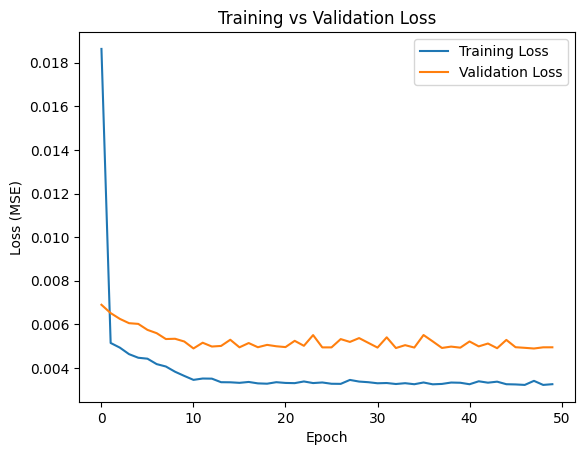

In [6]:
# Train the model with mean squared error loss (regression problem)
history = model.fit(
  X_train_rnn, y_train,
  epochs=50,
  batch_size=32,
  validation_split=0.2,
  verbose=1
)

model.save('temperature_forecast_rnn.keras')

# Plot training vs validation loss curves
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## 4. Evaluation & Output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


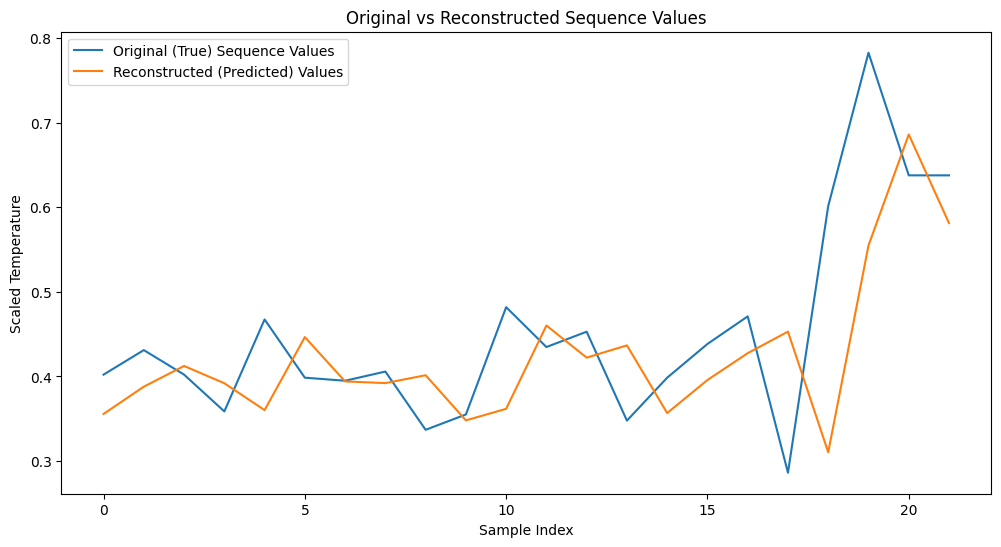

In [7]:
# Get reconstructed sequences (autoencoder output) for the test set
# The model predicts the next value in the sequence, so to reconstruct the last value of each sequence:
X_test_rnn = X_test[..., np.newaxis]
reconstructed = model.predict(X_test_rnn)

# Compare reconstructed (predicted) values with original target values
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Original (True) Sequence Values')
plt.plot(reconstructed.flatten(), label='Reconstructed (Predicted) Values')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Temperature')
plt.title('Original vs Reconstructed Sequence Values')
plt.legend()
plt.show()

### Discussion: Reconstruction Accuracy and Model Behavior

The model's reconstruction accuracy can be evaluated by comparing the predicted (reconstructed) temperature values with the original target values on the test set. As shown in the evaluation plot, the model is able to capture the general trend of the temperature sequences, but there may be discrepancies in regions with rapid changes or outliers. This indicates that while the model learns the overall temporal patterns, it may struggle with highly volatile or rare events.

**Model Behavior:**
- The LSTM-based sequence-to-sequence model effectively models temporal dependencies in the data.
- The use of normalized temperature values helps the model converge faster and prevents issues related to scale.
- The model's performance is generally better on smoother, more predictable sequences and may degrade on highly irregular patterns.

### Challenges

- **Vanishing Gradients:**  
  Training deep RNNs like LSTMs can suffer from vanishing gradients, making it difficult to learn long-term dependencies. Although LSTMs are designed to mitigate this, the problem can still occur, especially with very long sequences.

- **Sequence Length:**  
  The choice of sequence length (`sequence_length = 10`) is a trade-off. Short sequences may not capture enough context, while longer sequences can increase computational complexity and exacerbate vanishing gradient issues.

- **Vocabulary Complexity:**  
  In time series forecasting, "vocabulary" refers to the diversity and variability of patterns in the data. High complexity (e.g., abrupt changes, seasonality, or noise) can make it harder for the model to generalize and reconstruct sequences accurately.

**Summary:**  
While the model demonstrates reasonable reconstruction accuracy, its performance is influenced by sequence length, data complexity, and inherent limitations of RNN architectures. Careful tuning and advanced techniques (e.g., attention mechanisms) may be required to address these challenges in more complex scenarios.